# A part of Big Data Analysis 
------------
## The Flight dataset

Here the flight booking dataset of various Airlines is a scraped datewise from afamous website in a structured format. The dataset contains the record of fligh travel details between the cities in india . Here , multiple features are present like source & Destination city. Arrival & Departure time, Duration & price of the flight ets

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
pr2 = pd.read_csv(r"C:\Users\navee\Desktop\python libraries\Projects series\csv data sets\airlines_flights_data.csv")

In [5]:
pr2

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Cleaning DataSet

In [8]:
# remove the index column 
pr2.drop(columns = 'index', inplace=True)

In [9]:
pr2.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [10]:
# Get some Info about dataset
pr2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [11]:
# Get statistical summary about dataset 
pr2.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [12]:
pr2[pr2['duration'] == 49.830000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
193889,Air_India,AI-672,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
194359,Air_India,AI-672,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538


In [13]:
# check is that any missing value is present or not 
pr2.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

## Q1:  What are the airlines in dataset , accopanied by their frequencies

In [14]:
pr2.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [15]:
# Check how many flight present in DATASET and which one 
pr2['airline'].nunique()


6

In [16]:
pr2['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [17]:
# Show the all airlines with their frequencies 
pr2['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

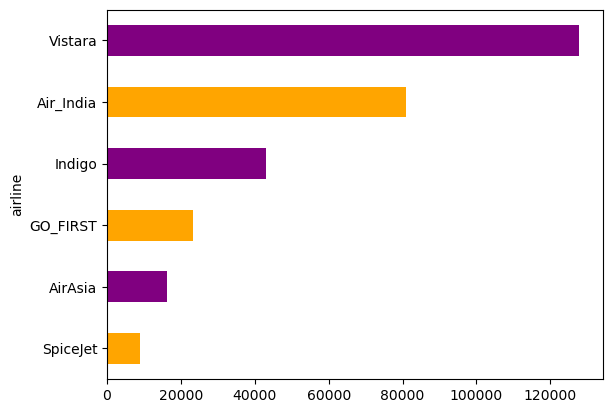

In [39]:
# Showing all the airlines with their Number of flights in Bar graph 
pr2['airline'].value_counts(ascending=True).plot.barh( color = ['orange', 'purple'])
plt.show( )


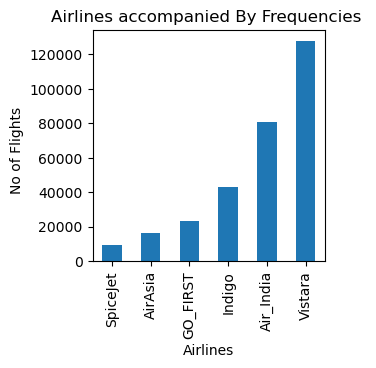

In [19]:
# You can also improve your graph by adding lables on y axis and x axix and custom size 
pr2['airline'].value_counts(ascending= True ).plot(
    kind = 'bar',
    figsize = (3,3),
    title = 'Airlines accompanied By Frequencies '
)
plt.xlabel('Airlines')
plt.ylabel('No of Flights  ')
plt.show()

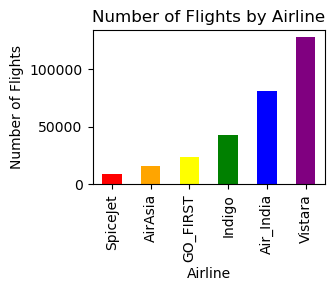

In [20]:
# change the colurs of above graph 
colors = [
    'red', 'orange', 'yellow', 'green', 'blue',
    'purple', 'brown', 'pink', 'gray', 'cyan'
]

pr2['airline'].value_counts(ascending=True).plot(
    kind='bar',
    figsize=(3,2),
    title='Number of Flights by Airline',
    color=colors
)

plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.show()


## Q2: Show Bar graphs representing the departure time and Arrival Time


In [21]:
pr2.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [22]:
# Show the departure time for the flights
pr2['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [23]:
# Show the Arrival time for the flights
pr2['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

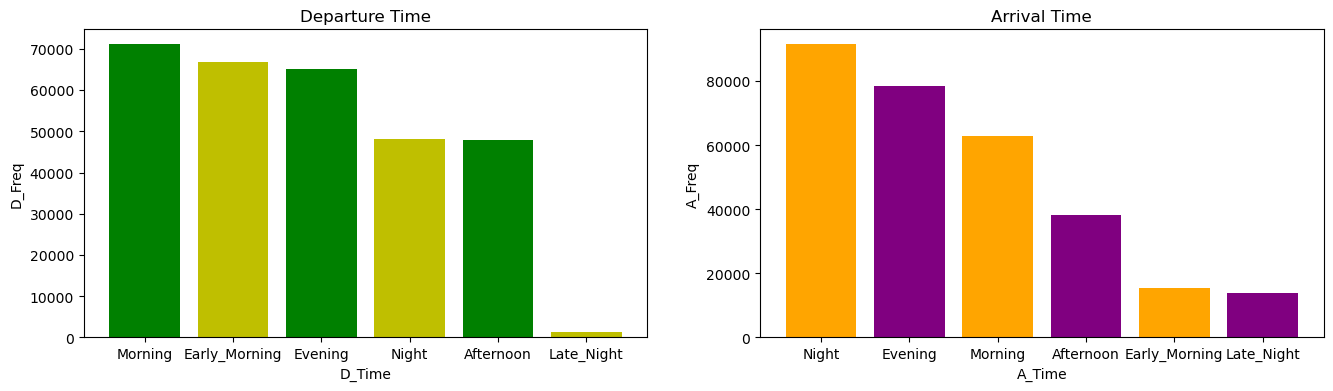

In [44]:
# Now show the departure & Arrival Time for flights with their counts 

plt.figure(figsize=(16,4))
plt.subplot(1,2,1)

plt.bar(pr2['departure_time'].value_counts().index, pr2['departure_time'].value_counts().values, color = ['g','y'])
plt.title('Departure Time')
plt.xlabel('D_Time')
plt.ylabel('D_Freq')

plt.subplot(1,2,2)
plt.bar(pr2['arrival_time'].value_counts().index, pr2['arrival_time'].value_counts().values, color = ['orange','purple'])
plt.title('Arrival Time')
plt.xlabel('A_Time')
plt.ylabel('A_Freq')
plt.show()

## SHow the Bar graph representing the source city & Destination City

In [45]:
pr2.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [46]:
# Showing te Source city of the flights 
pr2['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [47]:
# Showing te Destination city of the flights 
pr2['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

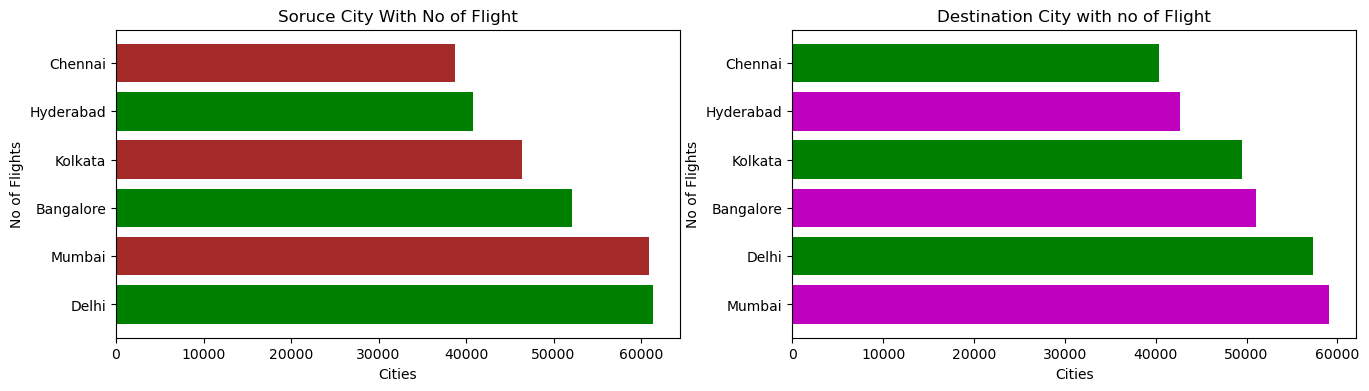

In [5]:
# Showing the source city and destinatio city for the flights with their counts by Bar graph 
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.barh(pr2['source_city'].value_counts().index, pr2['source_city'].value_counts().values, color = ['green', 'brown'])
plt.title('Soruce City With No of Flight')
plt.xlabel('Cities')
plt.ylabel('No of Flights')

plt.subplot(1,2,2)
plt.barh(pr2['destination_city'].value_counts().index, pr2['destination_city'].value_counts().values, color = ['m', 'g'])
plt.title('Destination City with no of Flight')
plt.xlabel('Cities')
plt.ylabel('No of Flights')
plt.show()


# Q3: Does prices varies with Airlines 

In [6]:
pr2.head(2)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [4]:
# Grouping The airlines and checking their mean prices 

pr2.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

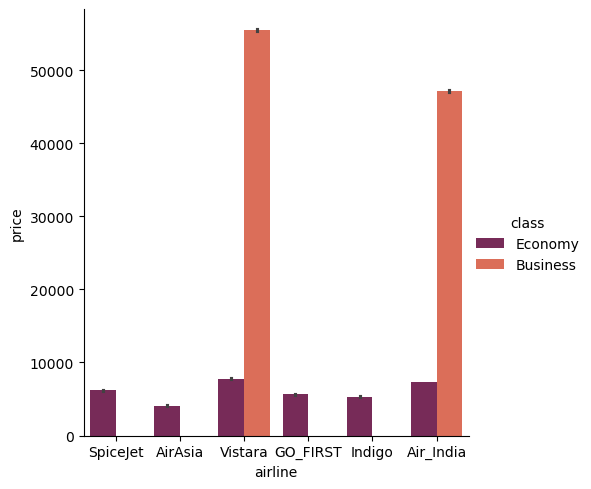

In [10]:
# Drawing a Categorical Plot showing the mean ticket price for each Airline
sns.catplot(x = 'airline', y = 'price',  kind = 'bar', palette='rocket',  data= pr2, hue= 'class')
plt.show()

## Q4: Does ticket price change based on the departure time and arrival time ?

In [4]:
pr2.head(1)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953


In [5]:
# checking the mean ticket price based on the departure time 
pr2.groupby('departure_time')['price'].mean()

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

In [6]:
# checking the mean ticket price based on the Arrival time 
pr2.groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64

<Figure size 200x200 with 0 Axes>

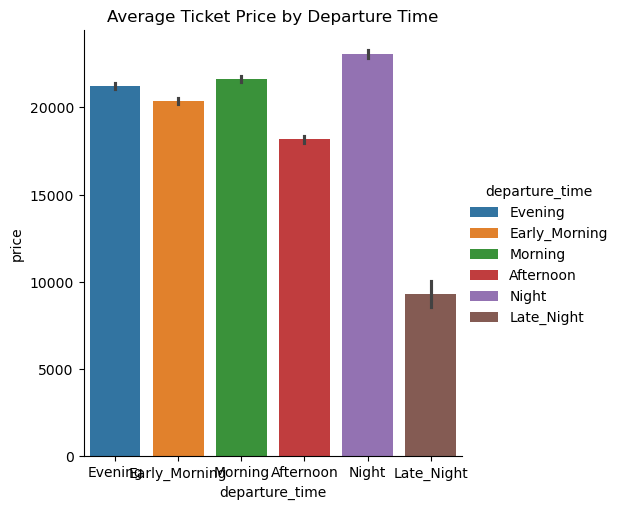

In [7]:
plt.figure(figsize=(2,2))
sns.catplot(x = 'departure_time',
            y = 'price', 
            hue = 'departure_time',   # hue batata hai “kis category ko alag color dena hai”
            kind = 'bar',
            legend=True,
            palette = "tab10" ,  # palette batata hai “wo colors kaun se hon ge”
            data = pr2)
plt.title('Average Ticket Price by Departure Time')
plt.show()
